# Amazon Sales Data Analysis and Visualization

## Project Overview
This project analyzes Amazon sales data to identify sales trends, customer purchasing patterns, product category performance, and regional sales distribution. The analysis includes data cleaning, exploratory data analysis (EDA), and visualizations to generate meaningful business insights.

### Objectives
- Understand the structure of the dataset
- Clean and prepare the data
- Perform Exploratory Data Analysis (EDA)
- Create meaningful visualizations
- Generate business insights from sales data

### Tools Used
- Python
- Pandas
- Matplotlib
- Jupyter Notebook

In [2]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Display graphs inside Jupyter Notebook
%matplotlib inline
print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# Load Dataset
df = pd.read_csv("Amazon Sale Report.csv")
print("Dataset loaded successfully.")

Dataset loaded successfully.


C:\Users\Bantu\AppData\Local\Temp\ipykernel_2952\3710248118.py:2: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Amazon Sale Report.csv")


## Dataset Overview

In [4]:
# Display first 5 rows
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


## Dataset Information

In [5]:
# Dataset Size
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])
# Dataset Information
df.info()

Rows : 128975
Columns : 24
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount 

## Statistical Summary

In [6]:
df.describe()

,index,Qty,Amount,ship-postal-code
count,128975.000000,128975.000000,121180.000000,128942.000000
mean,64487.000000,0.904431,648.561465,463966.236509
std,37232.019822,0.313354,281.211687,191476.764941
min,0.000000,0.000000,0.000000,110001.000000
25%,32243.500000,1.000000,449.000000,382421.000000
50%,64487.000000,1.000000,605.000000,500033.000000
75%,96730.500000,1.000000,788.000000,600024.000000
max,128974.000000,15.000000,5584.000000,989898.000000


## Missing Values

In [7]:
df.isnull().sum()

index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6872
Qty                       0
currency               7795
Amount                 7795
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
promotion-ids         49153
B2B                       0
fulfilled-by          89698
Unnamed: 22           49050
dtype: int64

## Duplicate Records

In [8]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


## Data Cleaning

In [9]:
# Remove duplicate rows
df = df.drop_duplicates()
# Check missing values again
df.isnull().sum()

index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6872
Qty                       0
currency               7795
Amount                 7795
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
promotion-ids         49153
B2B                       0
fulfilled-by          89698
Unnamed: 22           49050
dtype: int64

## Exploratory Data Analysis (EDA)

In [10]:
# Check unique order status
df["Status"].value_counts()

Status
Shipped                          77804
Shipped - Delivered to Buyer     28769
Cancelled                        18332
Shipped - Returned to Seller      1953
Shipped - Picked Up                973
Pending                            658
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipping                             8
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64

## Order Status Distribution

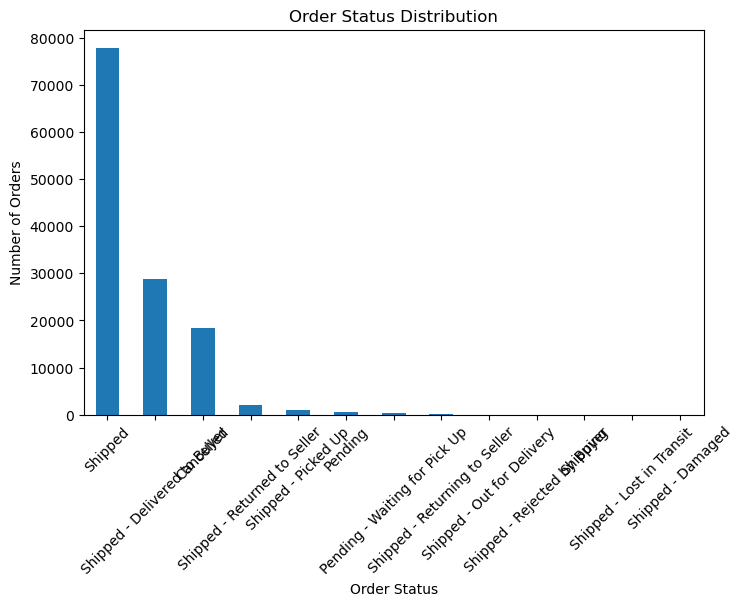

In [11]:
status = df["Status"].value_counts()
plt.figure(figsize=(8,5))
status.plot(kind="bar")
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

## Top 10 Product Categories

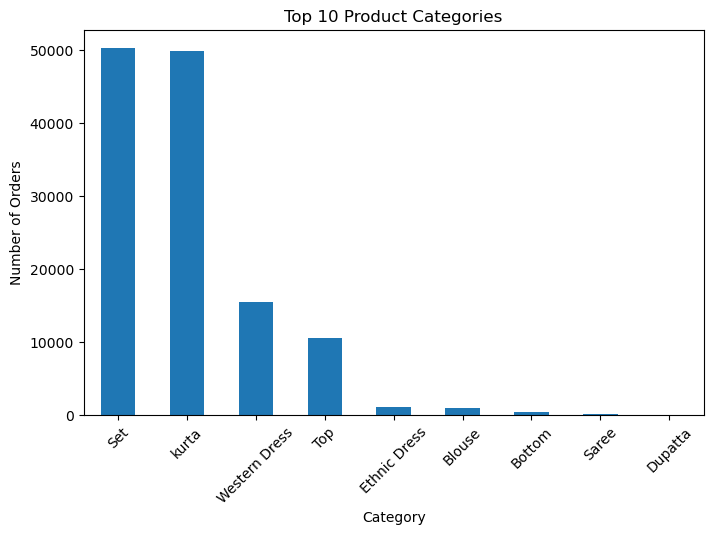

In [12]:
top_category = df["Category"].value_counts().head(10)
plt.figure(figsize=(8,5))
top_category.plot(kind="bar")
plt.title("Top 10 Product Categories")
plt.xlabel("Category")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

## Top 10 States by Orders

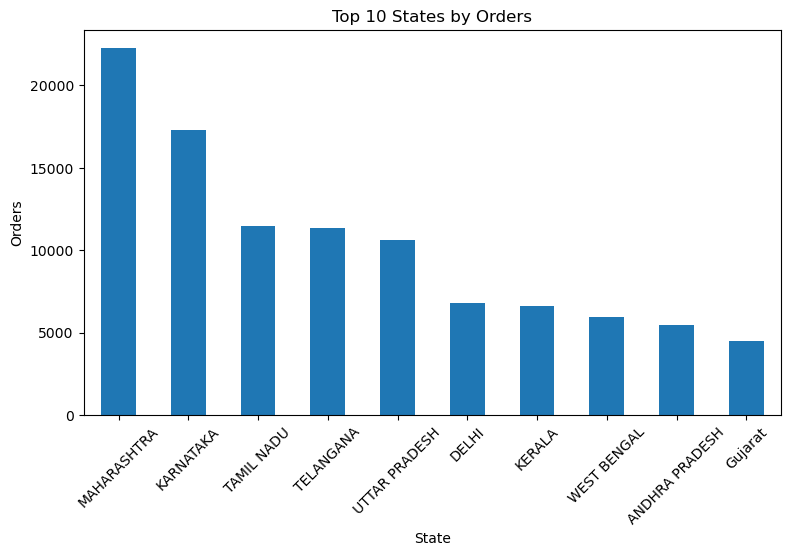

In [13]:
top_states = df["ship-state"].value_counts().head(10)
plt.figure(figsize=(9,5))
top_states.plot(kind="bar")
plt.title("Top 10 States by Orders")
plt.xlabel("State")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.show()

## Top 10 Cities by Orders

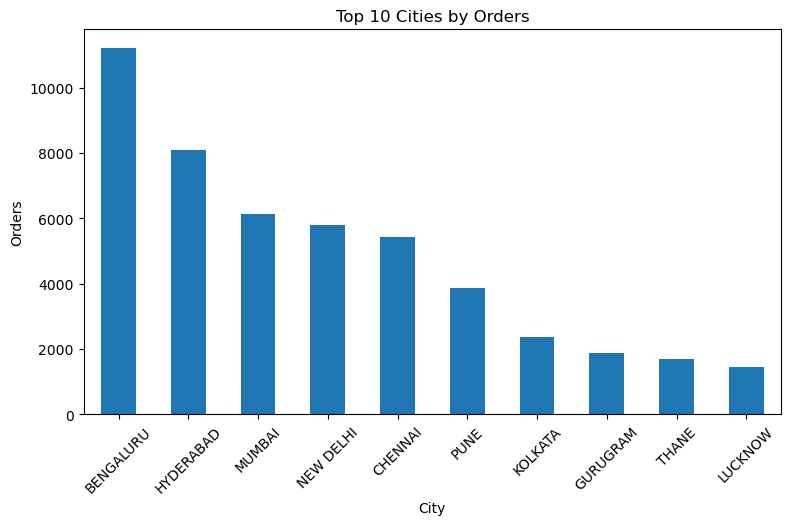

In [14]:
top_city = df["ship-city"].value_counts().head(10)
plt.figure(figsize=(9,5))
top_city.plot(kind="bar")
plt.title("Top 10 Cities by Orders")
plt.xlabel("City")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.show()

## Sales by Fulfilment Method

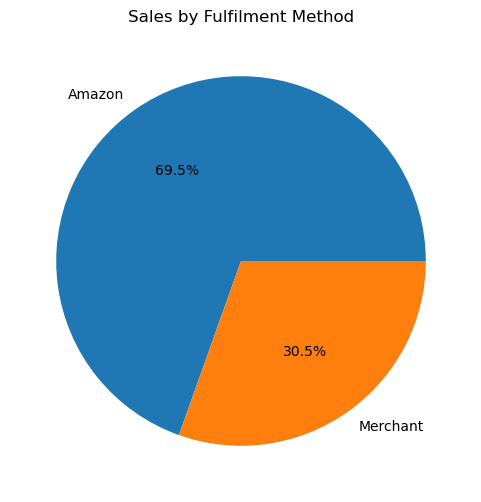

In [15]:
fulfillment = df["Fulfilment"].value_counts()
plt.figure(figsize=(6,6))
fulfillment.plot(kind="pie", autopct="%1.1f%%")
plt.ylabel("")
plt.title("Sales by Fulfilment Method")
plt.show()

## Observation

- Most orders are successfully shipped, making it the dominant order status.
- Delivered orders form the second largest group, indicating a good delivery success rate.
- Cancelled orders are significantly fewer than shipped orders, while returned and pending orders represent only a small portion of total orders.

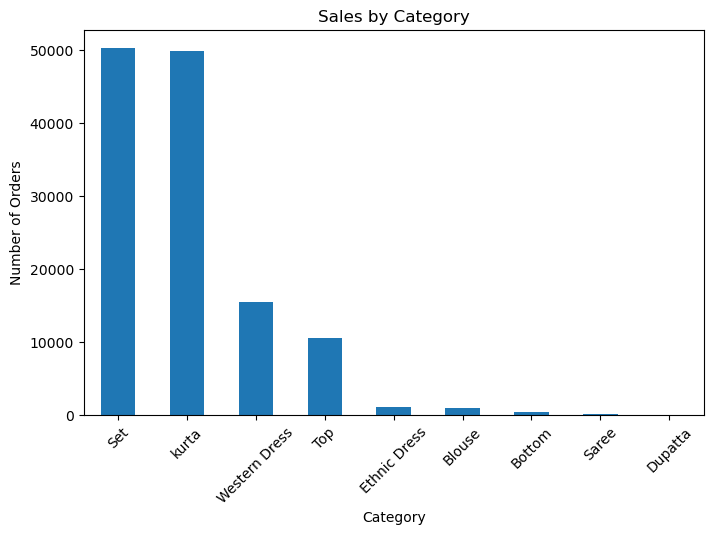

In [16]:
# Sales by Category
category = df["Category"].value_counts()
plt.figure(figsize=(8,5))
category.plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

## Observation

- Kurta category has the highest number of orders.
- Western Dress and Top categories have comparatively fewer orders.
- The dataset is dominated by a few product categories.

# Sales by State

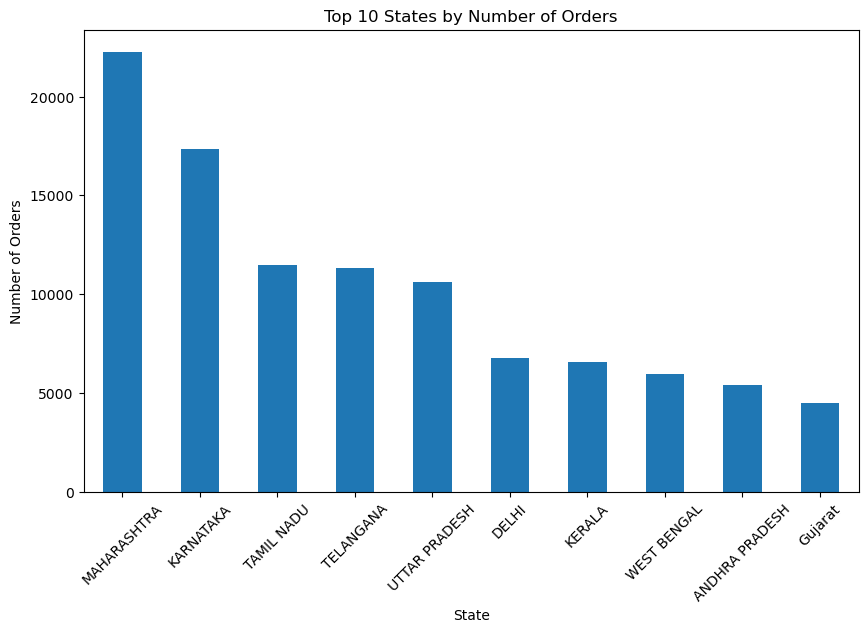

In [17]:
# Sales by State (Top 10)
state_sales = df["ship-state"].value_counts().head(10)
plt.figure(figsize=(10,6))
state_sales.plot(kind="bar")
plt.title("Top 10 States by Number of Orders")
plt.xlabel("State")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

## Observation

- Maharashtra records the highest number of orders.
- Karnataka and Tamil Nadu also contribute significantly to total sales.
- Most orders are concentrated in a few major states.

# Sales by Category

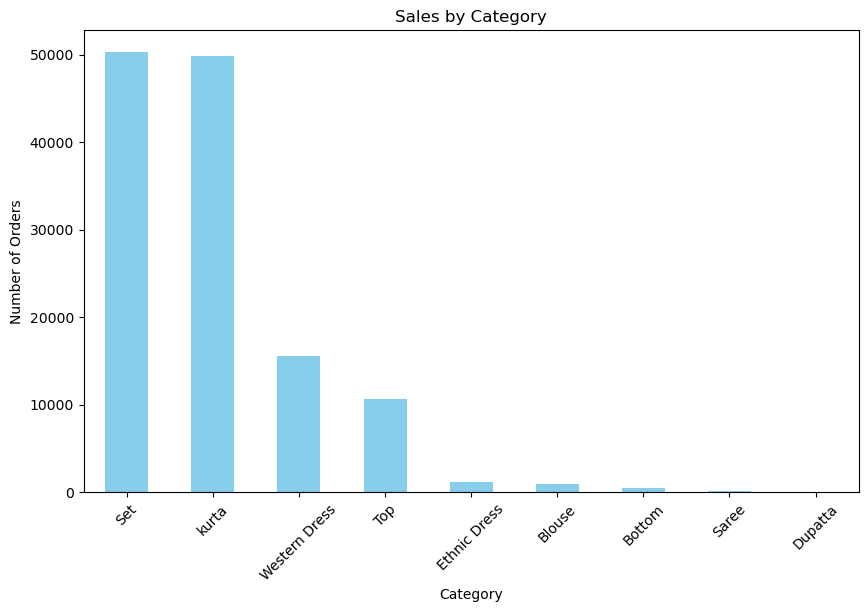

In [18]:
# Sales by Category
category_sales = df["Category"].value_counts()
plt.figure(figsize=(10,6))
category_sales.plot(kind="bar", color="skyblue")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

## Observation

- Kurta is the most frequently ordered product category.
- Set and Western Dress categories also receive a significant number of orders.
- Some categories contribute only a small percentage of total orders.

# Sales by Size

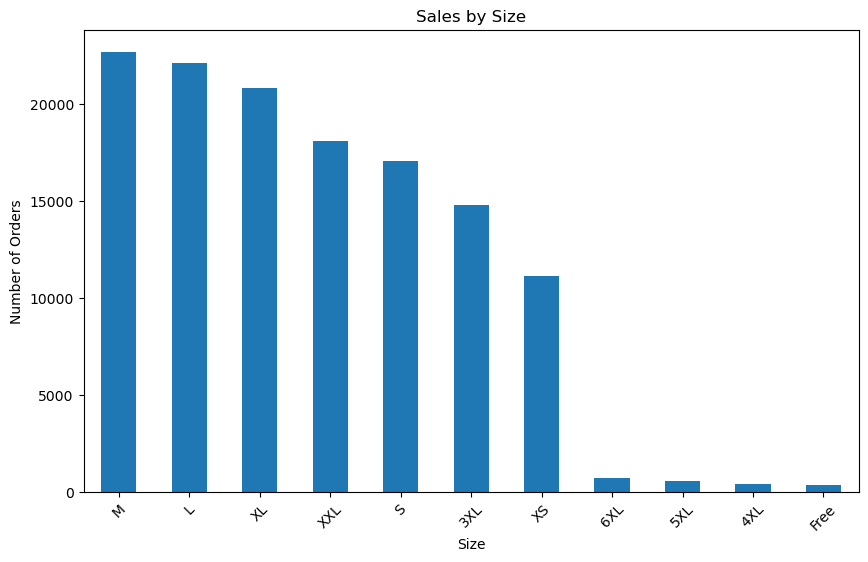

In [19]:
# Sales by Size
size_sales = df["Size"].value_counts()
plt.figure(figsize=(10,6))
size_sales.plot(kind="bar")
plt.title("Sales by Size")
plt.xlabel("Size")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

## Observation

- Medium (M) and Large (L) sizes have the highest number of orders.
- Very small and very large sizes receive comparatively fewer orders.
- Customer demand is concentrated around standard clothing sizes.

# Top 10 Cities by Number of Orders

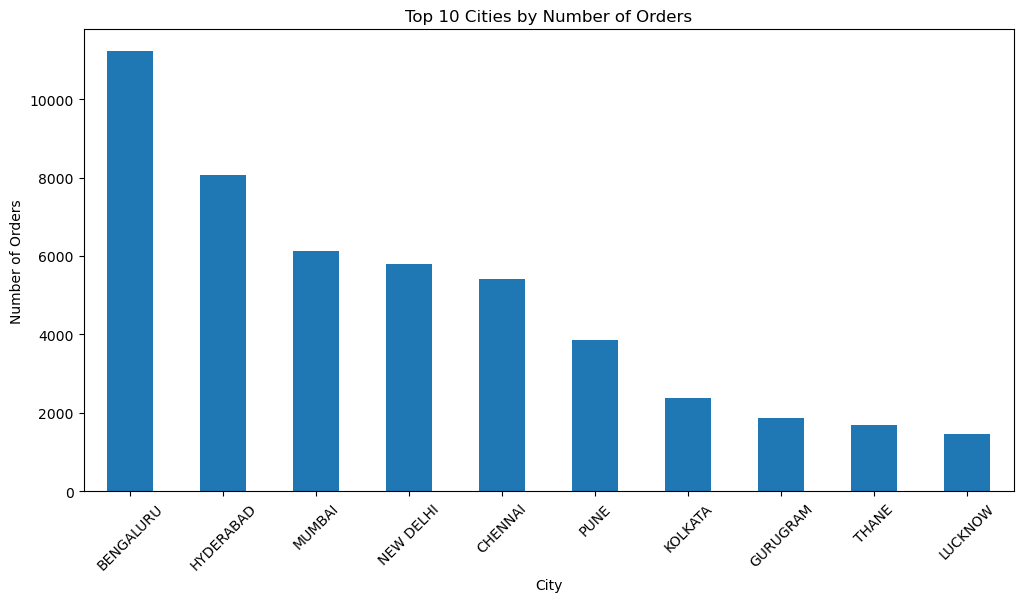

In [20]:
# Top 10 Cities by Orders
city_sales = df["ship-city"].value_counts().head(10)
plt.figure(figsize=(12,6))
city_sales.plot(kind="bar")
plt.title("Top 10 Cities by Number of Orders")
plt.xlabel("City")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

## Observation

- Bengaluru has the highest number of orders.
- Hyderabad, Mumbai, and Chennai are among the top ordering cities.
- Major metropolitan cities contribute the highest share of total orders.

# Conclusion

This project analyzed the Amazon Sales dataset to identify sales trends, customer purchasing patterns, and regional performance.

### Key Findings

- Most orders were successfully shipped.
- Amazon Fulfillment handled the majority of orders.
- Maharashtra recorded the highest number of orders among all states.
- Kurta was the most ordered product category.
- Medium (M) and Large (L) sizes were the most popular.
- Major metropolitan cities generated the highest number of orders.

### Business Insights

- Focus inventory on high-demand product categories and sizes.
- Strengthen logistics in top-performing states and cities.
- Continue improving fulfillment efficiency to maintain high delivery success.
- Use sales insights for better inventory planning and business decision-making.

**Overall, the analysis provides valuable insights that can help improve sales strategy, inventory management, and customer satisfaction.**